# Model Project

In [61]:
# Imports

from Consumer import ConsumerClass
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd

### 1 A consumer with two nets

In [62]:
# 1.2 Calibration
# Complements
model_complements = ConsumerClass()

# Substitutes
model_substitutes = ConsumerClass(
    par={"sigma_B": 3.0}
)

# 1.3 Check that the models are correctly specified
print("model_complements")
print(model_complements)
print()
print("model_substitutes")
print(model_substitutes)



model_complements
ConsumerClass
  alpha = 0.6000, beta = 0.5000
  sigma_A = 0.8000, sigma_B = 0.4000
  p1 = 1.0000, p2 = 1.0000, p3 = 1.5000
  I = 10.0000

model_substitutes
ConsumerClass
  alpha = 0.6000, beta = 0.5000
  sigma_A = 0.8000, sigma_B = 3.0000
  p1 = 1.0000, p2 = 1.0000, p3 = 1.5000
  I = 10.0000


## 2 Solving the model numercally

#### 2.1.3 N = 50, 100, 500 and 1000
The solution changes only slightly as N increases, while the number of utility evaluations increases substantially. This shows that a finer grid improves precision, but at a much higher computational cost.


#### 2.1.4 Comparing the two calibrations
The main difference between the two utility surfaces is in the w-direction.

For the complements calibration, the surface is relatively steep around the
optimum. Moving away from the optimal combination of bus and train therefore
reduces utility relatively quickly.

For the substitutes calibration, the surface is flatter in the w-direction.
Since bus and train can more easily substitute for each other, several values
of w give almost the same utility.

The two surfaces are more similar in the s1-direction because sigma_A is the
same in both calibrations.

We would therefore expect the substitutes calibration to be harder for an
optimizer, since the flatter surface makes the exact optimum more difficult
to locate.

#### 2.2.1 Compare the solutions

The two methods give almost the same solution for both calibrations.

For complements, the grid search gives $(s_1,w)=(0.535536,0.439439)$, while L-BFGS-B gives $(0.535623,0.439479)$. For substitutes, the grid search gives $(0.538539,0.692693)$, while L-BFGS-B gives $(0.538225,0.692308)$.

The main difference is computational efficiency. The grid search uses 1,000,000 function evaluations, while L-BFGS-B only uses 18 for complements and 27 for substitutes. L-BFGS-B is also much faster.

Therefore, the two methods agree very closely, but L-BFGS-B finds the solution with far fewer evaluations and a much lower running time.


#### 2.2.2 Convergence of L-BFGS-B

The convergence paths show that L-BFGS-B moves quickly toward the optimum in the first iterations and then makes smaller adjustments when it gets close to the final solution.

For the complements calibration, the distance to the final solution decreases very quickly after the first few iterations, and the optimizer reaches the optimum in only a few steps.

For the substitutes calibration, the optimizer needs slightly more iterations. This is consistent with the flatter utility surface in the w-direction, which makes it harder to identify the exact optimum.

Overall, the method makes the fastest progress when it is far from the optimum. Close to the optimum, the progress becomes slower because the optimizer makes smaller and more precise adjustments.

#### 2.2.3 Different starting points
For the substitutes calibration, all six starting points converge to approximately
the same solution, although the number of iterations differs.

For the complements calibration, most starting points also converge to the same
solution. However, starting at the corners with $s_1 = 1$ causes the optimizer to
stop close to the boundary with utility close to zero, even though the optimizer
reports `success = True`.

This shows that `success = True` does not necessarily imply that the global optimum
has been found. The result should therefore also be checked by comparing the achieved
utility across starting points.


### 2.2.5 Choice of tolerance settings
We would use `ftol = 1e-12` and `gtol = 1e-8`. These settings are sufficiently strict to obtain a very accurate solution, while avoiding unnecessary function evaluations.

A tighter tolerance is not always better. When the tolerance becomes very small, the optimizer may use more function evaluations without achieving a noticeable increase in utility. Numerical precision and the approximation of the gradient also limit how accurately the optimum can be found.

Since we are maximizing utility, we prefer settings that give a high utility with relatively few function evaluations. Therefore, there is little benefit from choosing the tightest possible tolerances if the resulting utility is essentially unchanged.

Calibration 1: Complements (sigma_B = 0.40)
Grid search with N=100
  s1 = 0.535354, w = 0.444444
  s1 = 0.535354, s2 = 0.206510, s3 = 0.258137
  utility = 3.401482
  function evaluations = 10000

Calibration 2: Substitutes (sigma_B = 3.00)
Grid search with N=100
  s1 = 0.535354, w = 0.696970
  s1 = 0.535354, s2 = 0.323845, s3 = 0.140802
  utility = 3.485005
  function evaluations = 10000


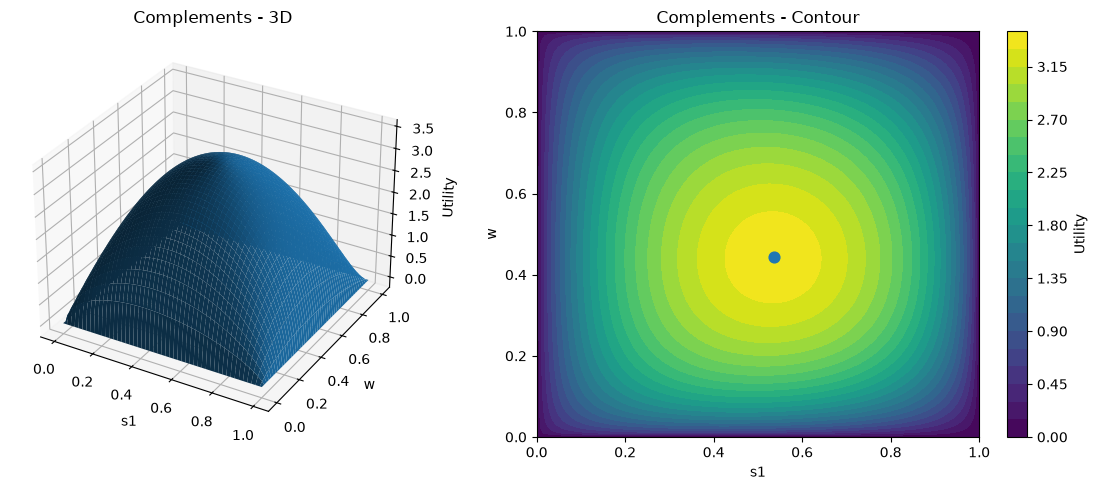

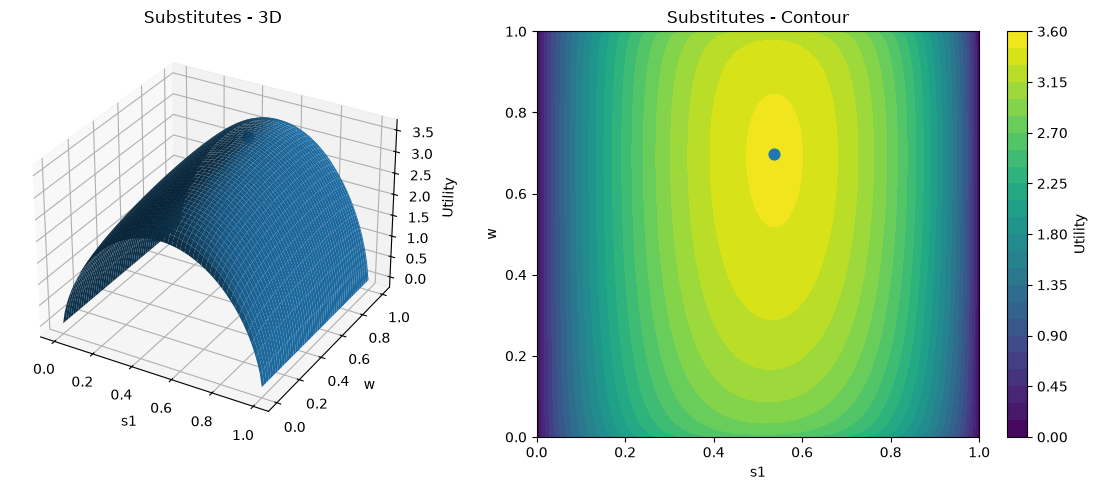

Complements
N =   50: s1 = 0.5306, w = 0.4490, u = 3.4007, evaluations = 2500
N =  100: s1 = 0.5354, w = 0.4444, u = 3.4015, evaluations = 10000
N =  500: s1 = 0.5351, w = 0.4389, u = 3.4017, evaluations = 250000
N = 1000: s1 = 0.5355, w = 0.4394, u = 3.4017, evaluations = 1000000

Substitutes
N =   50: s1 = 0.5306, w = 0.6939, u = 3.4846, evaluations = 2500
N =  100: s1 = 0.5354, w = 0.6970, u = 3.4850, evaluations = 10000
N =  500: s1 = 0.5391, w = 0.6914, u = 3.4851, evaluations = 250000
N = 1000: s1 = 0.5385, w = 0.6927, u = 3.4851, evaluations = 1000000

Complements

Grid search:
s1 = 0.5355
w  = 0.4394
u  = 3.4017
evaluations = 1000000
time = 0.0475 seconds

L-BFGS-B:
s1 = 0.5356
w  = 0.4395
u  = 3.4017
evaluations = 18
time = 0.0031 seconds

Substitutes

Grid search:
s1 = 0.5385
w  = 0.6927
u  = 3.4851
evaluations = 1000000
time = 0.0482 seconds

L-BFGS-B:
s1 = 0.5382
w  = 0.6923
u  = 3.4851
evaluations = 27
time = 0.0012 seconds


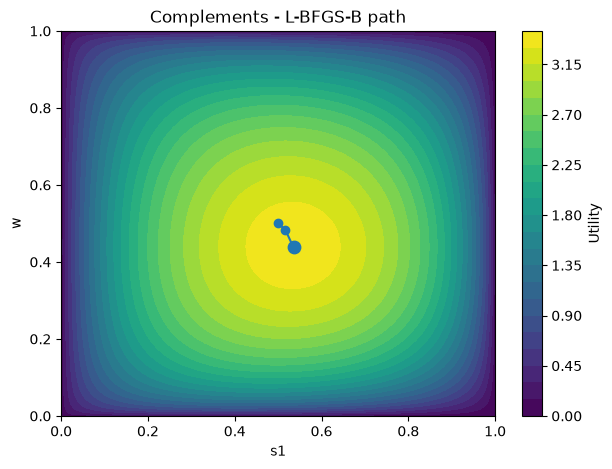

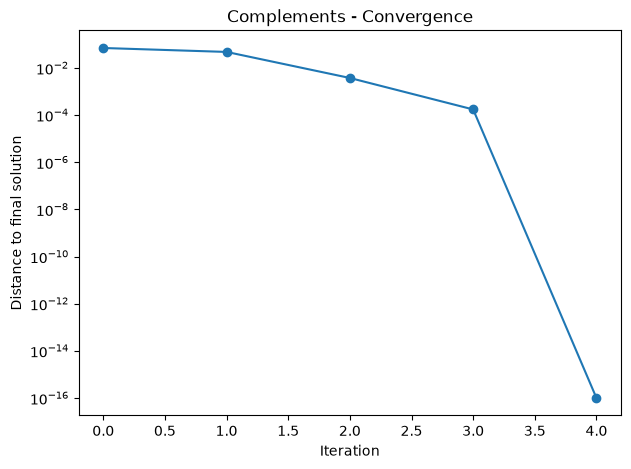

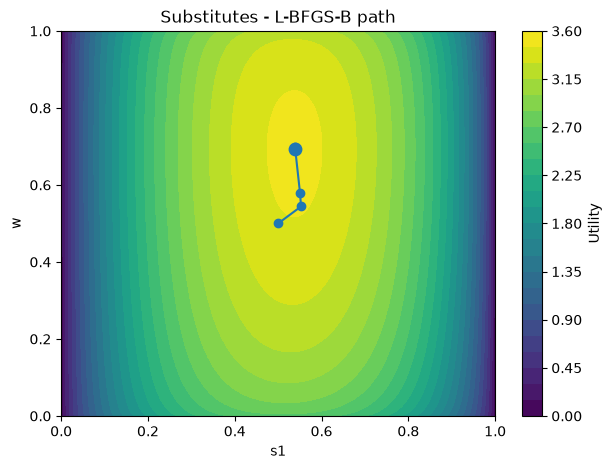

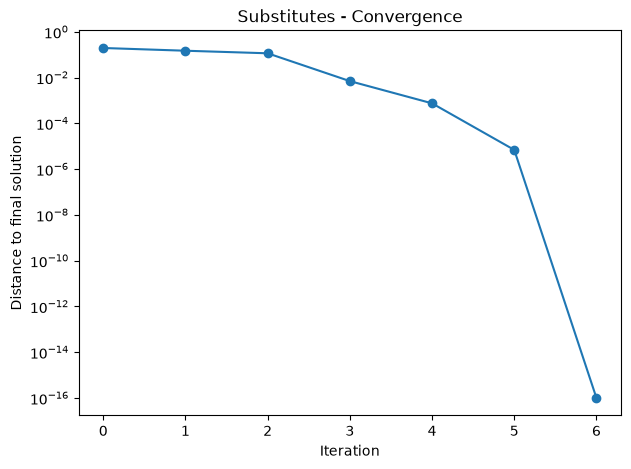

Complements

start = (0.50, 0.50)  -> s1 = 0.5356, w = 0.4395, u = 3.4017, iterations = 4, success = True
start = (0.00, 0.00)  -> s1 = 0.5356, w = 0.4395, u = 3.4017, iterations = 7, success = True
start = (0.00, 1.00)  -> s1 = 0.5356, w = 0.4395, u = 3.4017, iterations = 9, success = True
start = (1.00, 0.00)  -> s1 = 1.0000, w = 0.0000, u = 0.0000, iterations = 1, success = True
start = (1.00, 1.00)  -> s1 = 1.0000, w = 1.0000, u = 0.0000, iterations = 1, success = True
start = (0.25, 0.75)  -> s1 = 0.5356, w = 0.4395, u = 3.4017, iterations = 6, success = True

Substitutes

start = (0.50, 0.50)  -> s1 = 0.5382, w = 0.6923, u = 3.4851, iterations = 6, success = True
start = (0.00, 0.00)  -> s1 = 0.5382, w = 0.6923, u = 3.4851, iterations = 18, success = True
start = (0.00, 1.00)  -> s1 = 0.5382, w = 0.6923, u = 3.4851, iterations = 17, success = True
start = (1.00, 0.00)  -> s1 = 0.5382, w = 0.6923, u = 3.4851, iterations = 18, success = True
start = (1.00, 1.00)  -> s1 = 0.5382, w 

,Calibration,Setting,Tolerance,s1,w,Utility,Evaluations
0,Complements,ftol,1.000000e-04,0.535607,0.439652,3.401680,15
1,Complements,ftol,1.000000e-08,0.535623,0.439479,3.401680,18
2,Complements,ftol,1.000000e-12,0.535623,0.439479,3.401680,18
3,Complements,ftol,1.000000e-16,0.535623,0.439479,3.401680,18
4,Complements,gtol,1.000000e-02,0.535607,0.439652,3.401680,15
5,Complements,gtol,1.000000e-05,0.535623,0.439479,3.401680,18
6,Complements,gtol,1.000000e-08,0.535624,0.439478,3.401680,21
7,Complements,gtol,1.000000e-12,0.535624,0.439478,3.401680,21
8,Substitutes,ftol,1.000000e-04,0.538155,0.691562,3.485104,21
9,Substitutes,ftol,1.000000e-08,0.538225,0.692308,3.485105,27


In [ ]:
## 2.1 A two-dimensional grid search


# 2.1.1 Make a grid of N values of w (use solve_grid)
# Calibration 1: Complements
print("Calibration 1: Complements (sigma_B = 0.40)")
sol_comp = model_complements.solve_grid(N=100)

print()

# Calibration 2: Substitutes
print("Calibration 2: Substitutes (sigma_B = 3.00)")
sol_sub = model_substitutes.solve_grid(N=100)


# 2.1.2 Plot utility over the nested shares
def plot_grid_solution(sol, title):

    fig = plt.figure(figsize=(12, 5))

    # 3D plot
    ax = fig.add_subplot(1, 2, 1, projection='3d')

    ax.plot_surface(
        sol.s1_grid,
        sol.w_grid,
        sol.u_grid
    )

    ax.scatter(
        sol.s1,
        sol.w,
        sol.u,
        s=60
    )

    ax.set_xlabel('s1')
    ax.set_ylabel('w')
    ax.set_zlabel('Utility')
    ax.set_title(f'{title} - 3D')

    # Contour plot
    ax = fig.add_subplot(1, 2, 2)

    contour = ax.contourf(
        sol.s1_grid,
        sol.w_grid,
        sol.u_grid,
        levels=30
    )

    ax.scatter(
        sol.s1,
        sol.w,
        s=60
    )

    ax.set_xlabel('s1')
    ax.set_ylabel('w')
    ax.set_title(f'{title} - Contour')

    fig.colorbar(contour, ax=ax, label='Utility')

    plt.tight_layout()
    plt.show()


plot_grid_solution(
    sol_comp,
    'Complements'
)

plot_grid_solution(
    sol_sub,
    'Substitutes'
)


# 2.1.3 Trying N = 50, 500 and 1000
N_values = [50, 100, 500, 1000]

print("Complements")

for N in N_values:
    sol = model_complements.solve_grid(N=N, do_print=False)

    print(
        f"N = {N:4d}: "
        f"s1 = {sol.s1:.4f}, "
        f"w = {sol.w:.4f}, "
        f"u = {sol.u:.4f}, "
        f"evaluations = {sol.nfev}"
    )


print()
print("Substitutes")

for N in N_values:
    sol = model_substitutes.solve_grid(N=N, do_print=False)

    print(
        f"N = {N:4d}: "
        f"s1 = {sol.s1:.4f}, "
        f"w = {sol.w:.4f}, "
        f"u = {sol.u:.4f}, "
        f"evaluations = {sol.nfev}"
    )




## 2.2 L-BFGS-B

# 2.2.1 Solving the problem
print()
# Complements

# Grid search
start = time.perf_counter()
grid_comp = model_complements.solve_grid(N=1000, do_print=False)
time_grid_comp = time.perf_counter() - start

# L-BFGS-B
start = time.perf_counter()
lbfgs_comp = model_complements.solve(do_print=False)
time_lbfgs_comp = time.perf_counter() - start

print("Complements")
print()
print("Grid search:")
print(f"s1 = {grid_comp.s1:.4f}")
print(f"w  = {grid_comp.w:.4f}")
print(f"u  = {grid_comp.u:.4f}")
print(f"evaluations = {grid_comp.nfev}")
print(f"time = {time_grid_comp:.4f} seconds")

print()

print("L-BFGS-B:")
print(f"s1 = {lbfgs_comp.s1:.4f}")
print(f"w  = {lbfgs_comp.w:.4f}")
print(f"u  = {lbfgs_comp.u:.4f}")
print(f"evaluations = {lbfgs_comp.res.nfev}")
print(f"time = {time_lbfgs_comp:.4f} seconds")

print()
# Substitutes

# Grid search
start = time.perf_counter()
grid_sub = model_substitutes.solve_grid(N=1000, do_print=False)
time_grid_sub = time.perf_counter() - start

# L-BFGS-B
start = time.perf_counter()
lbfgs_sub = model_substitutes.solve(do_print=False)
time_lbfgs_sub = time.perf_counter() - start

print("Substitutes")
print()
print("Grid search:")
print(f"s1 = {grid_sub.s1:.4f}")
print(f"w  = {grid_sub.w:.4f}")
print(f"u  = {grid_sub.u:.4f}")
print(f"evaluations = {grid_sub.nfev}")
print(f"time = {time_grid_sub:.4f} seconds")

print()

print("L-BFGS-B:")
print(f"s1 = {lbfgs_sub.s1:.4f}")
print(f"w  = {lbfgs_sub.w:.4f}")
print(f"u  = {lbfgs_sub.u:.4f}")
print(f"evaluations = {lbfgs_sub.res.nfev}")
print(f"time = {time_lbfgs_sub:.4f} seconds")


# 2.2.2 Record the convergence pathwith the callback argument of optimize.minimize
def plot_convergence(grid_sol, lbfgs_sol, title):

    # Alt herinde hører til funktionen
    fig, ax = plt.subplots(figsize=(7, 5))

    contour = ax.contourf(
        grid_sol.s1_grid,
        grid_sol.w_grid,
        grid_sol.u_grid,
        levels=30
    )

    path = lbfgs_sol.path

    ax.plot(
        path[:, 0],
        path[:, 1],
        marker='o'
    )

    ax.scatter(
        lbfgs_sol.s1,
        lbfgs_sol.w,
        s=80
    )

    ax.set_xlabel('s1')
    ax.set_ylabel('w')
    ax.set_title(f'{title} - L-BFGS-B path')

    fig.colorbar(contour, ax=ax, label='Utility')

    plt.show()

    final_point = np.array([
        lbfgs_sol.s1,
        lbfgs_sol.w
    ])

    distances = np.linalg.norm(
        path - final_point,
        axis=1
    )

    distances = np.maximum(distances, 1e-16)

    plt.figure(figsize=(7, 5))

    plt.semilogy(
        range(len(distances)),
        distances,
        marker='o'
    )

    plt.xlabel('Iteration')
    plt.ylabel('Distance to final solution')
    plt.title(f'{title} - Convergence')

    plt.show()


plot_convergence(
    grid_comp,
    lbfgs_comp,
    'Complements'
)

plot_convergence(
    grid_sub,
    lbfgs_sub,
    'Substitutes'
)

    


# 2.2.3 Solve from six different starting points
# Six starting points
starting_points = [
    np.array([0.5, 0.5]),  # middle
    np.array([0.0, 0.0]),  # corner
    np.array([0.0, 1.0]),  # corner
    np.array([1.0, 0.0]),  # corner
    np.array([1.0, 1.0]),  # corner
    np.array([0.25, 0.75]) # extra starting point
]

def check_starting_points(model, title):

    print(title)
    print()

    for s0 in starting_points:

        sol = model.solve(
            s0=s0,
            do_print=False
        )

        print(
            f"start = ({s0[0]:.2f}, {s0[1]:.2f})  "
            f"-> s1 = {sol.s1:.4f}, "
            f"w = {sol.w:.4f}, "
            f"u = {sol.u:.4f}, "
            f"iterations = {sol.res.nit}, "
            f"success = {sol.res.success}"
        )

    print()


# Complements
check_starting_points(
    model_complements,
    "Complements"
)

# Substitutes
check_starting_points(
    model_substitutes,
    "Substitutes"
)




# 2.2.4 Report the two shares
import pandas as pd

# Tolerance values
ftol_values = [1e-4, 1e-8, 1e-12, 1e-16]
gtol_values = [1e-2, 1e-5, 1e-8, 1e-12]

results = []

def test_tolerances(model, calibration):

    # Test ftol
    for ftol in ftol_values:

        sol = model.solve(
            s0=np.array([0.5, 0.5]),
            do_print=False,
            options={'ftol': ftol}
        )

        results.append({
            'Calibration': calibration,
            'Setting': 'ftol',
            'Tolerance': ftol,
            's1': sol.s1,
            'w': sol.w,
            'Utility': sol.u,
            'Evaluations': sol.res.nfev
        })

    # Test gtol
    for gtol in gtol_values:

        sol = model.solve(
            s0=np.array([0.5, 0.5]),
            do_print=False,
            options={'gtol': gtol}
        )

        results.append({
            'Calibration': calibration,
            'Setting': 'gtol',
            'Tolerance': gtol,
            's1': sol.s1,
            'w': sol.w,
            'Utility': sol.u,
            'Evaluations': sol.res.nfev
        })


# Complements
test_tolerances(
    model_complements,
    'Complements'
)

# Substitutes
test_tolerances(
    model_substitutes,
    'Substitutes'
)

# Make table
results_df = pd.DataFrame(results)

results_df


### 3 Relative prices and demand

#### 3.2 Effect of the train price on the train budget share

In the complements calibration, a higher train price increases the budget share spent on train. Since bus and train are complements, the consumer does not easily substitute away from train when it becomes more expensive. Therefore, a larger share of the budget is needed to pay for train trips.

In the substitutes calibration, a higher train price decreases the budget share spent on train. Here, the consumer can more easily replace train trips with bus trips when train becomes more expensive, so spending shifts away from train and toward bus.

Therefore, a higher $p_3$ raises the train budget share for complements, but lowers it for substitutes.

#### 3.3 Effect of the train price on bus trips

The number of bus trips reacts very differently across the two calibrations.

For complements, the number of bus trips falls when the train price increases. Since bus and train are complements, the consumer wants to use them together. When train becomes more expensive and train demand falls, bus demand also falls.

For substitutes, the number of bus trips increases strongly when the train price increases. Since bus and train can replace each other, the consumer switches from train to bus when train becomes more expensive.

Therefore, a higher train price reduces bus demand for complements, but increases bus demand for substitutes.

#### 3.4 Effect of the train price on food demand

The demand for food changes much less than the demand for bus trips when the train price increases.

For complements, food demand falls from about 5.62 to 5.15 when the train price increases from 0.5 to 3.0. Bus demand falls more, from about 2.64 to 1.66.

For substitutes, food demand also falls slightly, from about 5.69 to 5.32. In contrast, bus demand changes much more and increases from about 0.86 to 4.21 because consumers substitute away from train and toward bus.

Overall, the train price has a relatively small effect on food demand, while the effect on bus demand is much larger, especially in the substitutes calibration.

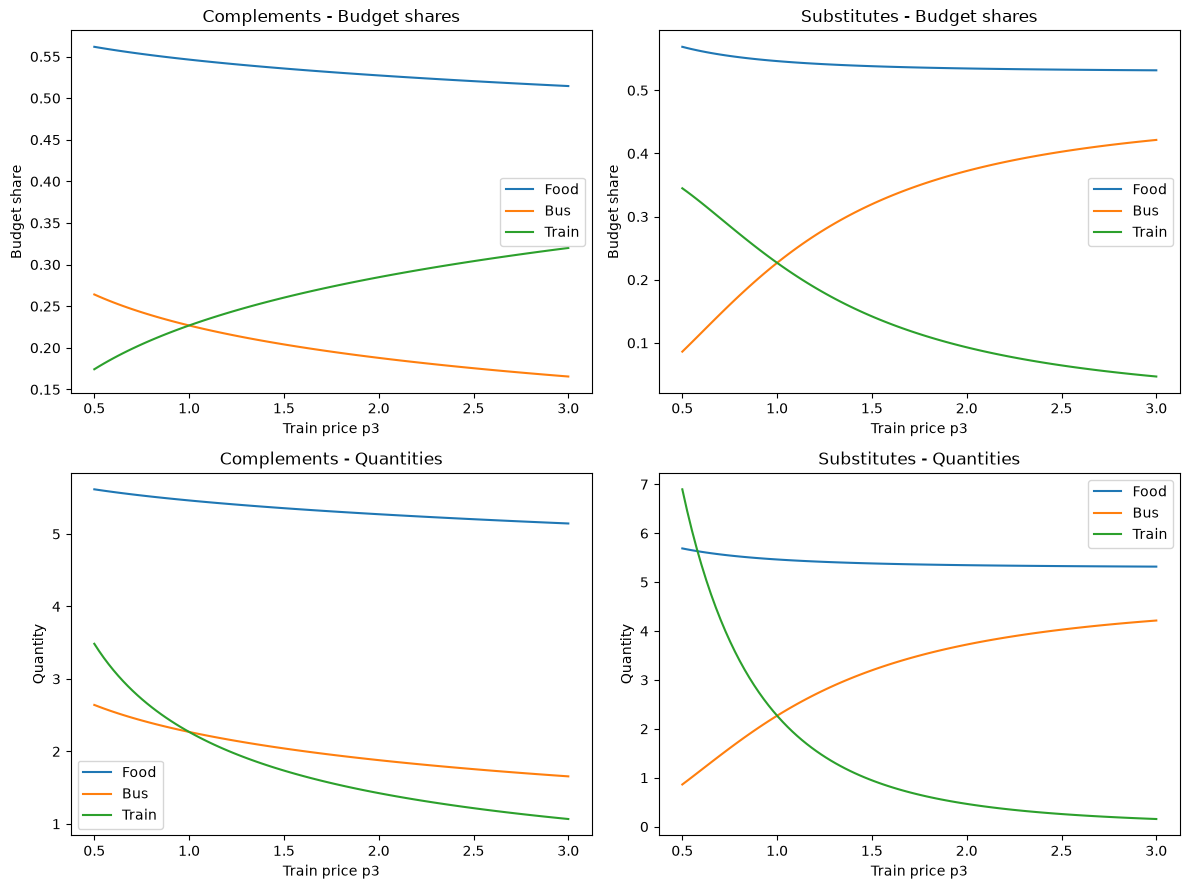

In [ ]:
# 3.1 Solve the model
# Values of the train price
p3_values = np.linspace(0.5, 3.0, 100)

def solve_for_p3(model, p3_values):

    # Empty lists for budget shares
    s1_values = []
    s2_values = []
    s3_values = []

    # Empty lists for quantities
    x1_values = []
    x2_values = []
    x3_values = []

    # Save original train price
    p3_original = model.par.p3

    for p3 in p3_values:

        # Change the price of train tickets
        model.par.p3 = p3

        # Solve the consumer problem
        sol = model.solve(do_print=False)

        # Save budget shares
        s1_values.append(sol.s1)
        s2_values.append(sol.s2)
        s3_values.append(sol.s3)

        # Calculate and save quantities
        x1, x2, x3 = model.quantities(sol.s1, sol.w)

        x1_values.append(x1)
        x2_values.append(x2)
        x3_values.append(x3)

    # Restore original train price
    model.par.p3 = p3_original

    return {
        's1': np.array(s1_values),
        's2': np.array(s2_values),
        's3': np.array(s3_values),
        'x1': np.array(x1_values),
        'x2': np.array(x2_values),
        'x3': np.array(x3_values)
    }


# Solve for both calibrations
results_comp = solve_for_p3(
    model_complements,
    p3_values
)

results_sub = solve_for_p3(
    model_substitutes,
    p3_values
)

fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 9)
)

# Complements: budget shares
ax = axes[0, 0]

ax.plot(p3_values, results_comp['s1'], label='Food')
ax.plot(p3_values, results_comp['s2'], label='Bus')
ax.plot(p3_values, results_comp['s3'], label='Train')

ax.set_xlabel('Train price p3')
ax.set_ylabel('Budget share')
ax.set_title('Complements - Budget shares')
ax.legend()


# Substitutes: budget shares
ax = axes[0, 1]

ax.plot(p3_values, results_sub['s1'], label='Food')
ax.plot(p3_values, results_sub['s2'], label='Bus')
ax.plot(p3_values, results_sub['s3'], label='Train')

ax.set_xlabel('Train price p3')
ax.set_ylabel('Budget share')
ax.set_title('Substitutes - Budget shares')
ax.legend()


# Complements: quantities
ax = axes[1, 0]

ax.plot(p3_values, results_comp['x1'], label='Food')
ax.plot(p3_values, results_comp['x2'], label='Bus')
ax.plot(p3_values, results_comp['x3'], label='Train')

ax.set_xlabel('Train price p3')
ax.set_ylabel('Quantity')
ax.set_title('Complements - Quantities')
ax.legend()


# Substitutes: quantities
ax = axes[1, 1]

ax.plot(p3_values, results_sub['x1'], label='Food')
ax.plot(p3_values, results_sub['x2'], label='Bus')
ax.plot(p3_values, results_sub['x3'], label='Train')

ax.set_xlabel('Train price p3')
ax.set_ylabel('Quantity')
ax.set_title('Substitutes - Quantities')
ax.legend()


plt.tight_layout()
plt.show()


## 4 Lump-sum taxes and product taxes
#### 4.3 Maximum tax revenue
The revenue curves do not all behave in the same way. In the substitutes
calibration, taxes on bus only and train only have a clear maximum. A sufficiently
high tax causes the consumer to substitute strongly towards the untaxed transport
good, so revenue eventually falls.

The maximum revenue from taxing train tickets alone in the substitutes calibration
is approximately 0.259, obtained at a tax rate of about 0.59.

For the other instruments, the revenue curves are still increasing over the range
considered, so no interior maximum is found on the grid.

#### 4.4 Utility and tax revenue

The lump-sum tax and the tax on all goods are the cheapest ways to raise a given amount of revenue, since they give the highest consumer utility for a given revenue. The two curves are almost identical because taxing all goods at the same rate does not change their relative prices.

The other product taxes change relative prices and therefore distort the consumer's choices. This results in a larger loss of utility for the same amount of revenue.

The ranking does depend on the calibration. For complements, a tax on train is less costly than a tax on bus. For substitutes, this is reversed: a tax on bus is less costly than a tax on train. This happens because consumers can substitute much more strongly between bus and train in the substitutes calibration.

Overall, lump-sum taxation and an equal tax on all goods are the least costly instruments, while the ranking of the individual product taxes depends on whether bus and train are complements or substitutes.


#### 4.5 Rank of instruments
For both calibrations, the lump-sum tax and a uniform tax on all goods give the
highest utility for a revenue requirement of R = 0.20.

Targeted product taxes generate lower utility because they distort relative prices.
This effect is especially strong for the train tax in the substitutes calibration,
where the consumer can substitute strongly from train towards bus.

The ranking of the tax instruments therefore depends on how easily the consumer can
substitute between the taxed and untaxed goods.

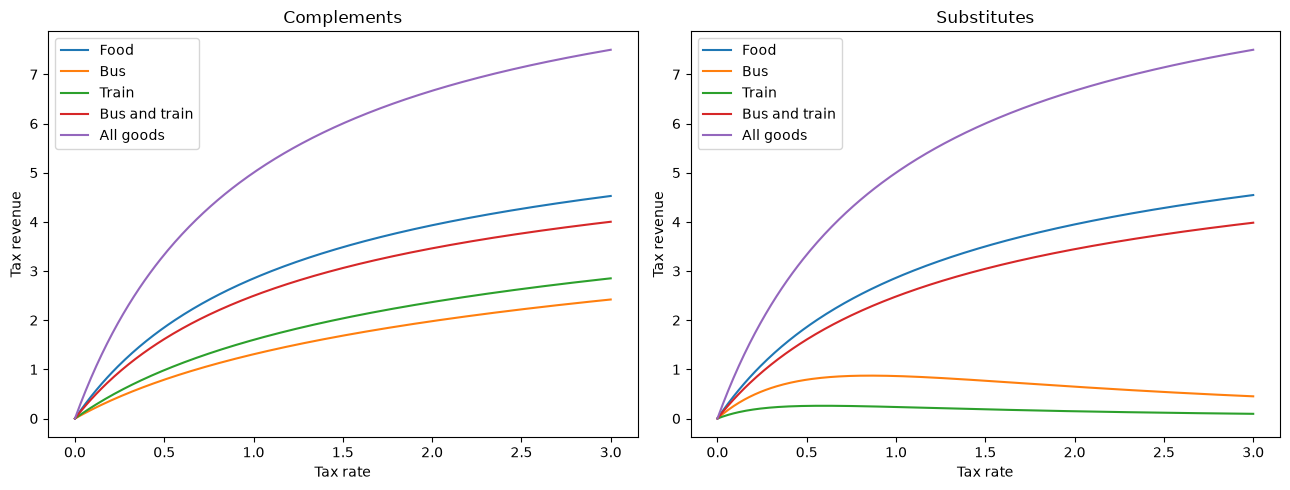

Complements

Food: revenue is still rising at tau = 10.0
Bus: revenue is still rising at tau = 10.0
Train: revenue is still rising at tau = 10.0
Bus and train: revenue is still rising at tau = 10.0
All goods: revenue is still rising at tau = 10.0

Substitutes

Food: revenue is still rising at tau = 10.0
Bus: tau* = 0.860, max revenue = 0.8721
Train: tau* = 0.590, max revenue = 0.2590
Bus and train: revenue is still rising at tau = 10.0
All goods: revenue is still rising at tau = 10.0



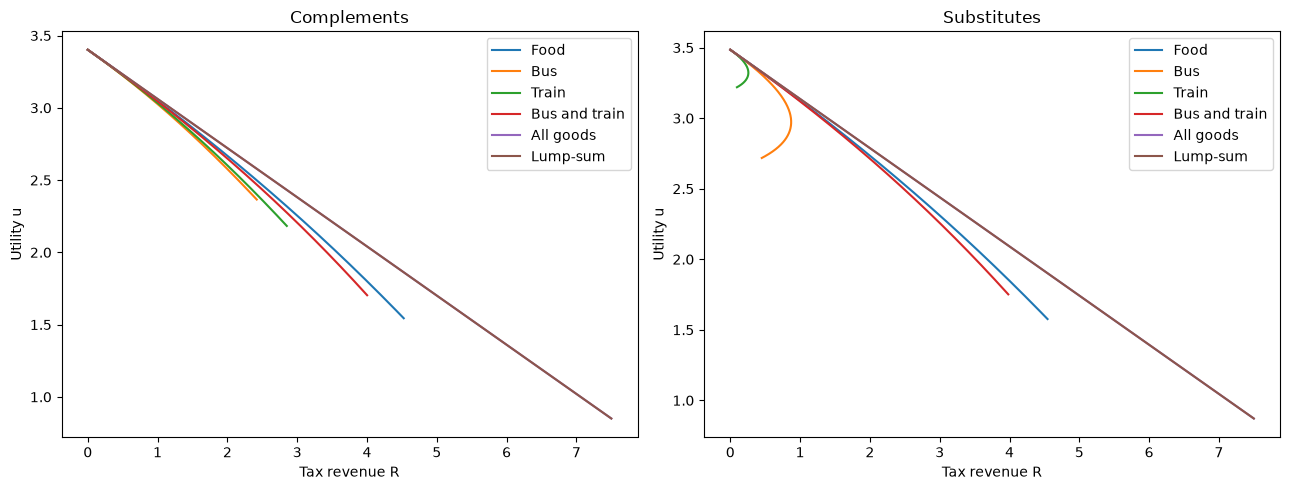

Complements


,Instrument,Tax,Revenue,Utility,Rank
5,Lump-sum,0.200000,0.2,3.333646,1.0
4,All goods,0.020408,0.2,3.333646,2.0
0,Food,0.038647,0.2,3.333169,3.0
3,Bus and train,0.044787,0.2,3.333010,4.0
2,Train,0.081011,0.2,3.332548,5.0
1,Bus,0.104215,0.2,3.332260,6.0


Substitutes


,Instrument,Tax,Revenue,Utility,Rank
4,All goods,0.020408,0.2,3.415402,1.0
5,Lump-sum,0.200000,0.2,3.415402,2.0
0,Food,0.038454,0.2,3.414919,3.0
3,Bus and train,0.045049,0.2,3.414744,4.0
1,Bus,0.069532,0.2,3.412375,5.0
2,Train,0.236217,0.2,3.395521,6.0


In [ ]:
# 4.1 Implement tax_revenue() (eq. 5).
from Government import GovernmentClass

# Calibration 1: Complements
gov_comp = GovernmentClass()

# Calibration 2: Substitutes
gov_sub = GovernmentClass(
    par={'sigma_B': 3.0}
)


# 4.2 Product taxes
taxes = {
    'Food': (1,),
    'Bus': (2,),
    'Train': (3,),
    'Bus and train': (2, 3),
    'All goods': (1, 2, 3)
}

tau_values = np.linspace(0, 3, 301)


def calculate_revenue(model, tau_values, taxes):

    results = {}

    for name, goods in taxes.items():

        revenues = []

        for tau in tau_values:

            R, u = model.revenue_and_utility(
                tau,
                goods=goods
            )

            revenues.append(R)

        results[name] = np.array(revenues)

    return results


revenue_comp = calculate_revenue(
    gov_comp,
    tau_values,
    taxes
)

revenue_sub = calculate_revenue(
    gov_sub,
    tau_values,
    taxes
)

# Laver figur
fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 5)
)

# Complements
ax = axes[0]

for name in taxes:
    ax.plot(
        tau_values,
        revenue_comp[name],
        label=name
    )

ax.set_xlabel('Tax rate')
ax.set_ylabel('Tax revenue')
ax.set_title('Complements')
ax.legend()


# Substitutes
ax = axes[1]

for name in taxes:
    ax.plot(
        tau_values,
        revenue_sub[name],
        label=name
    )

ax.set_xlabel('Tax rate')
ax.set_ylabel('Tax revenue')
ax.set_title('Substitutes')
ax.legend()

plt.tight_layout()
plt.show()


# 4.3 Revenue-maximizing tax rates
taxes = {
    'Food': (1,),
    'Bus': (2,),
    'Train': (3,),
    'Bus and train': (2, 3),
    'All goods': (1, 2, 3)
}

def check_max_revenue(model, title, tau_max=10.0):

    print(title)
    print()

    for name, goods in taxes.items():

        tau_star, R_max = model.max_revenue(
            goods=goods,
            tau_max=tau_max,
            N=1001
        )

        if np.isclose(tau_star, tau_max):
            print(
                f"{name}: revenue is still rising at tau = {tau_max:.1f}"
            )
        else:
            print(
                f"{name}: "
                f"tau* = {tau_star:.3f}, "
                f"max revenue = {R_max:.4f}"
            )

    print()


check_max_revenue(
    gov_comp,
    'Complements'
)

check_max_revenue(
    gov_sub,
    'Substitutes'
)
# 4.4 Plot of the consumer’s utility against the revenue raised

taxes = {
    'Food': (1,),
    'Bus': (2,),
    'Train': (3,),
    'Bus and train': (2, 3),
    'All goods': (1, 2, 3)
}

tau_values = np.linspace(0, 3, 301)


def utility_revenue_curves(model):

    results = {}

    # Product taxes
    for name, goods in taxes.items():

        revenues = []
        utilities = []

        for tau in tau_values:

            R, u = model.revenue_and_utility(
                tau,
                goods=goods
            )

            revenues.append(R)
            utilities.append(u)

        results[name] = {
            'R': np.array(revenues),
            'u': np.array(utilities)
        }

    # Find largest revenue shown by the product taxes
    max_R = max(
        np.max(results[name]['R'])
        for name in taxes
    )

    # Lump-sum tax: R = T
    T_values = np.linspace(
        0,
        min(max_R, 0.99 * model.par.I_pre),
        301
    )

    revenues = []
    utilities = []

    for T in T_values:

        R, u = model.revenue_and_utility_lump_sum(T)

        revenues.append(R)
        utilities.append(u)

    results['Lump-sum'] = {
        'R': np.array(revenues),
        'u': np.array(utilities)
    }

    return results


results_44_comp = utility_revenue_curves(gov_comp)
results_44_sub = utility_revenue_curves(gov_sub)

# Lav figurer
fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 5)
)

# Complements
ax = axes[0]

for name, result in results_44_comp.items():
    ax.plot(
        result['R'],
        result['u'],
        label=name
    )

ax.set_xlabel('Tax revenue R')
ax.set_ylabel('Utility u')
ax.set_title('Complements')
ax.legend()


# Substitutes
ax = axes[1]

for name, result in results_44_sub.items():
    ax.plot(
        result['R'],
        result['u'],
        label=name
    )

ax.set_xlabel('Tax revenue R')
ax.set_ylabel('Utility u')
ax.set_title('Substitutes')
ax.legend()

plt.tight_layout()
plt.show()

# 4.5 Let the government need R = 0.20, i.e. 2 percent of income
R_target = 0.20

# The five product tax instruments
tax_instruments = {
    'Food': (1,),
    'Bus': (2,),
    'Train': (3,),
    'Bus and train': (2, 3),
    'All goods': (1, 2, 3)
}


def make_tax_table(model):

    # Empty list for the results
    results = []

    # Find the tax rate for each product tax
    for name, goods in tax_instruments.items():

        # Find tau such that revenue is exactly 0.20
        tau = model.find_tax_rate(
            R_target,
            goods=goods,
            bracket=(1e-10, 1.0)
        )

        # If a solution exists, calculate revenue and utility
        if not np.isnan(tau):

            R, u = model.revenue_and_utility(
                tau,
                goods=goods
            )

        else:

            R = np.nan
            u = np.nan

        # Save the results
        results.append({
            'Instrument': name,
            'Tax': tau,
            'Revenue': R,
            'Utility': u
        })

    # Lump-sum tax raises exactly T in revenue
    T = R_target

    # Calculate utility with the lump-sum tax
    R, u = model.revenue_and_utility_lump_sum(T)

    # Save lump-sum result
    results.append({
        'Instrument': 'Lump-sum',
        'Tax': T,
        'Revenue': R,
        'Utility': u
    })

    # Convert results to a dataframe
    df = pd.DataFrame(results)

    # Rank instruments: highest utility is best
    df['Rank'] = df['Utility'].rank(
        ascending=False,
        method='min'
    )

    # Sort from best to worst
    df = df.sort_values('Rank')

    return df


# Complements
table_comp = make_tax_table(gov_comp)

print("Complements")
display(table_comp)

# Substitutes
table_sub = make_tax_table(gov_sub)

print("Substitutes")
display(table_sub)

### 5 Extension

#### 5 Extension: Different preferences for bus and train

We extend the model by introducing two different types of consumers. Both consumers are in the substitutes calibration with $\sigma_B = 3.0$, but they have different preferences for bus and train.

The bus-preferring consumer has $\beta = 0.70$, while the train-preferring consumer has $\beta = 0.30$. All other parameters are kept unchanged. This allows us to study how differences in preferences affect the response to changes in the train price and to different product taxes.

The first figure shows that the two consumers have very different initial consumption patterns. At the baseline train price $p_3 = 1.5$, the bus-preferring consumer spends about 43 percent of the budget on bus and only about 1.5 percent on train. The train-preferring consumer spends about 7 percent on bus and about 39 percent on train.

When the train price increases, both consumers substitute from train towards bus. However, the effect is much stronger for the train-preferring consumer. The bus-preferring consumer already uses mainly bus, so a higher train price has a relatively small effect on the consumption pattern. The train-preferring consumer initially uses much more train and therefore changes behavior more when train becomes expensive.

The second figure shows that preferences also affect how much revenue different product taxes can raise. A tax on bus generates more revenue from the bus-preferring consumer, while a tax on train generates more revenue from the train-preferring consumer. This is because the government can initially collect more revenue from the good that the consumer buys more of.

At high tax rates, revenue from a tax on only bus or only train can eventually fall. Since bus and train are substitutes, the consumer can avoid the taxed good by switching towards the untaxed alternative.

Overall, the extension shows that consumer preferences are important for both demand responses and tax revenue. The effect of a price increase or a product tax depends not only on how substitutable the goods are, but also on which good the consumer initially prefers.

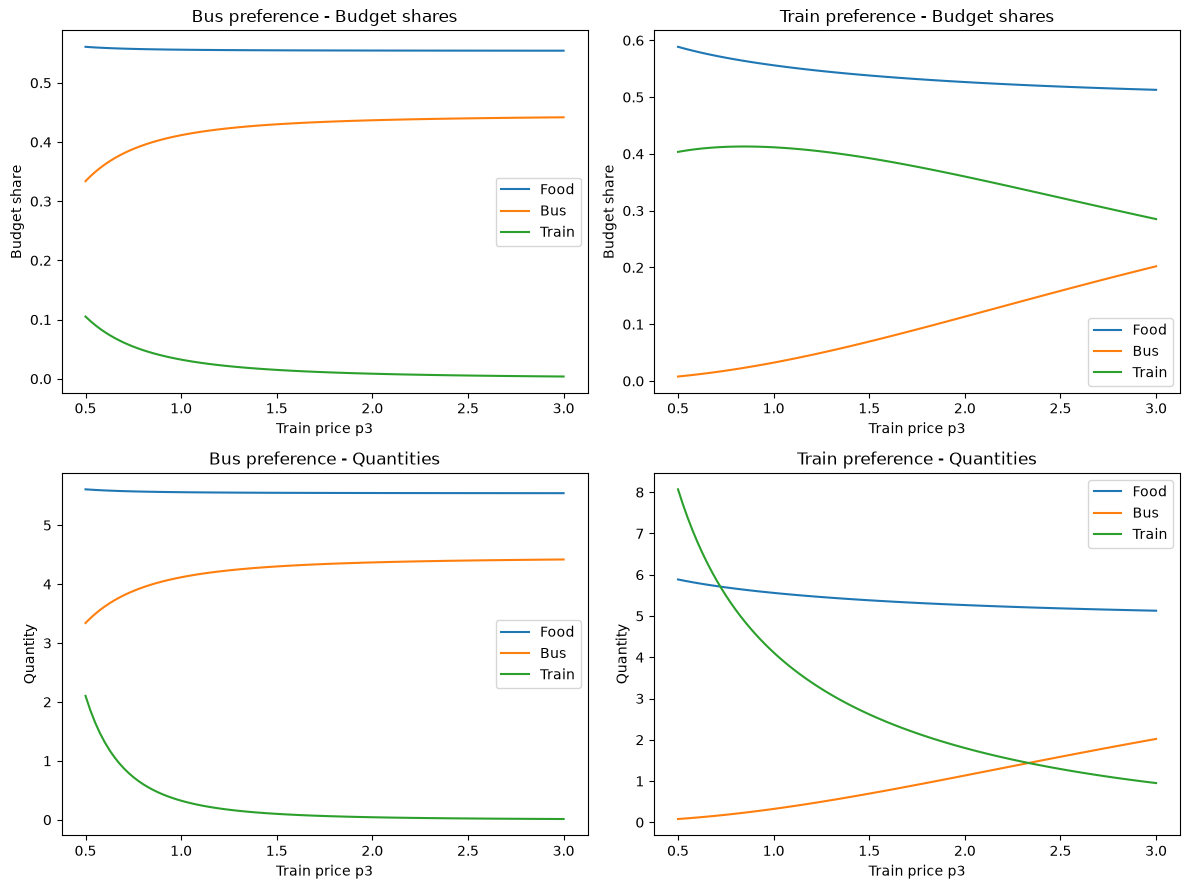

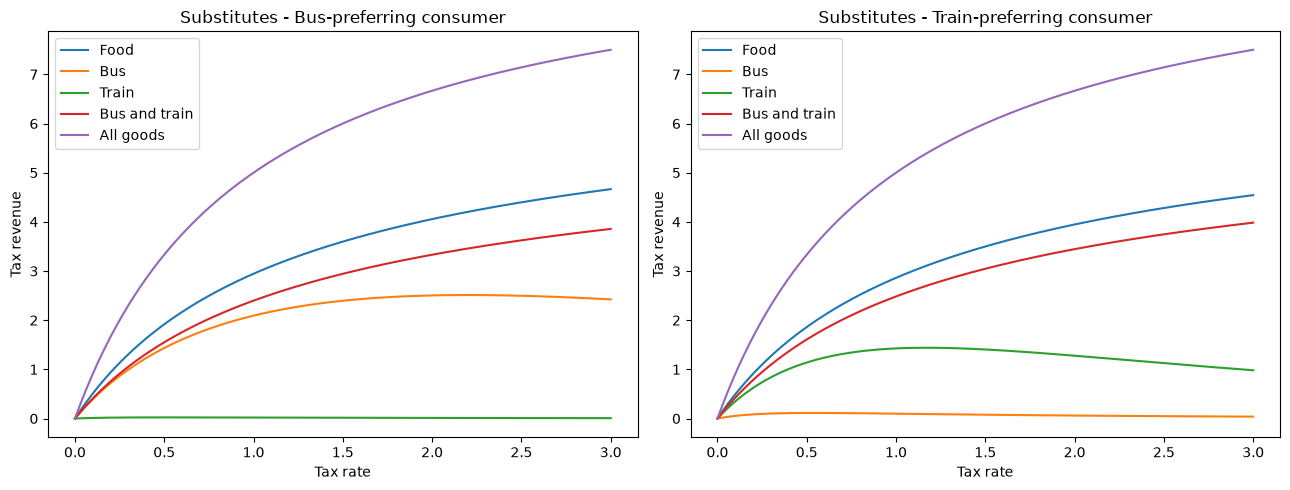

In [ ]:
# Consumer who prefers bus more
## 5 Extension: Two consumer types in the substitutes calibration

# Consumer who prefers bus more
consumer_bus = ConsumerClass(
    par={
        'sigma_B': 3.0,
        'beta': 0.70
    }
)

# Consumer who prefers train more
consumer_train = ConsumerClass(
    par={
        'sigma_B': 3.0,
        'beta': 0.30
    }
)

# Train prices from 0.5 to 3.0
p3_values = np.linspace(0.5, 3.0, 100)

# Solve the model for all train prices
results_bus = solve_for_p3(
    consumer_bus,
    p3_values
)

results_train = solve_for_p3(
    consumer_train,
    p3_values
)

# Create a figure with four panels
fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 9)
)

# Bus-preferring consumer: budget shares
ax = axes[0, 0]

ax.plot(p3_values, results_bus['s1'], label='Food')
ax.plot(p3_values, results_bus['s2'], label='Bus')
ax.plot(p3_values, results_bus['s3'], label='Train')

ax.set_xlabel('Train price p3')
ax.set_ylabel('Budget share')
ax.set_title('Bus preference - Budget shares')
ax.legend()


# Train-preferring consumer: budget shares
ax = axes[0, 1]

ax.plot(p3_values, results_train['s1'], label='Food')
ax.plot(p3_values, results_train['s2'], label='Bus')
ax.plot(p3_values, results_train['s3'], label='Train')

ax.set_xlabel('Train price p3')
ax.set_ylabel('Budget share')
ax.set_title('Train preference - Budget shares')
ax.legend()


# Bus-preferring consumer: quantities
ax = axes[1, 0]

ax.plot(p3_values, results_bus['x1'], label='Food')
ax.plot(p3_values, results_bus['x2'], label='Bus')
ax.plot(p3_values, results_bus['x3'], label='Train')

ax.set_xlabel('Train price p3')
ax.set_ylabel('Quantity')
ax.set_title('Bus preference - Quantities')
ax.legend()


# Train-preferring consumer: quantities
ax = axes[1, 1]

ax.plot(p3_values, results_train['x1'], label='Food')
ax.plot(p3_values, results_train['x2'], label='Bus')
ax.plot(p3_values, results_train['x3'], label='Train')

ax.set_xlabel('Train price p3')
ax.set_ylabel('Quantity')
ax.set_title('Train preference - Quantities')
ax.legend()


# Make the figure fit nicely
plt.tight_layout()
plt.show()

#figur 2
# Two consumer types, both with substitutes
gov_bus = GovernmentClass(
    par={'sigma_B': 3.0, 'beta': 0.70}
)

gov_train = GovernmentClass(
    par={'sigma_B': 3.0, 'beta': 0.30}
)

# Tax rates from 0 to 3
tau_values = np.linspace(0, 3, 301)

# Tax instruments
taxes_extension = {
    'Food': (1,),
    'Bus': (2,),
    'Train': (3,),
    'Bus and train': (2, 3),
    'All goods': (1, 2, 3)
}

# Calculate tax revenue for each consumer type
def calculate_extension_revenue(model):

    results = {}

    # Loop over the five tax instruments
    for name, goods in taxes_extension.items():

        revenues = []

        # Try all tax rates
        for tau in tau_values:

            # Calculate revenue
            R, u = model.revenue_and_utility(
                tau,
                goods=goods
            )

            # Save revenue
            revenues.append(R)

        results[name] = np.array(revenues)

    return results


# Calculate revenue curves
revenue_bus_type = calculate_extension_revenue(gov_bus)
revenue_train_type = calculate_extension_revenue(gov_train)


# Create figure with two panels
fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 5)
)

# Bus-preferring consumer
ax = axes[0]

for name in taxes_extension:
    ax.plot(
        tau_values,
        revenue_bus_type[name],
        label=name
    )

ax.set_xlabel('Tax rate')
ax.set_ylabel('Tax revenue')
ax.set_title('Substitutes - Bus-preferring consumer')
ax.legend()


# Train-preferring consumer
ax = axes[1]

for name in taxes_extension:
    ax.plot(
        tau_values,
        revenue_train_type[name],
        label=name
    )

ax.set_xlabel('Tax rate')
ax.set_ylabel('Tax revenue')
ax.set_title('Substitutes - Train-preferring consumer')
ax.legend()


# Make figure fit nicely
plt.tight_layout()
plt.show()